# Exam

First let's import the data and see what 

In [117]:
import  pandas as pd 

df = pd.read_csv("data/depression.csv")
df.head()

,id,Gender,Age,City,Profession,Academic Pressure,Work Pressure,CGPA,Study Satisfaction,Job Satisfaction,Sleep Duration,Dietary Habits,Degree,Have you ever had suicidal thoughts ?,Work/Study Hours,Financial Stress,Family History of Mental Illness,Depression
0,2,Male,33.0,Visakhapatnam,Student,5.0,0.0,8.97,2.0,0.0,'5-6 hours',Healthy,B.Pharm,Yes,3.0,1.0,No,1
1,8,Female,24.0,Bangalore,Student,2.0,0.0,5.90,5.0,0.0,'5-6 hours',Moderate,BSc,No,3.0,2.0,Yes,0
2,26,Male,31.0,Srinagar,Student,3.0,0.0,7.03,5.0,0.0,'Less than 5 hours',Healthy,BA,No,9.0,1.0,Yes,0
3,30,Female,28.0,Varanasi,Student,3.0,0.0,5.59,2.0,0.0,'7-8 hours',Moderate,BCA,Yes,4.0,5.0,Yes,1
4,32,Female,25.0,Jaipur,Student,4.0,0.0,8.13,3.0,0.0,'5-6 hours',Moderate,M.Tech,Yes,1.0,1.0,No,0


**id** doesn't have any meaningful data for prediction that's why I will drop it.

In [118]:
df = df.drop('id', axis=1)

In [119]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 27901 entries, 0 to 27900
Data columns (total 17 columns):
 #   Column                                 Non-Null Count  Dtype  
---  ------                                 --------------  -----  
 0   Gender                                 27901 non-null  object 
 1   Age                                    27901 non-null  float64
 2   City                                   27901 non-null  object 
 3   Profession                             27901 non-null  object 
 4   Academic Pressure                      27901 non-null  float64
 5   Work Pressure                          27901 non-null  float64
 6   CGPA                                   27901 non-null  float64
 7   Study Satisfaction                     27901 non-null  float64
 8   Job Satisfaction                       27901 non-null  float64
 9   Sleep Duration                         27901 non-null  object 
 10  Dietary Habits                         27901 non-null  object 
 11  De

I wanted to see all the columns that have object as dtype.
 
This 
Gender, City, Profession, Sleep Duration, Dietary Habits, Degree, Have you ever had suicidal thoughts ?, Financial Stress, Family History of Mental Illness.

In [120]:
df.describe()

,Age,Academic Pressure,Work Pressure,CGPA,Study Satisfaction,Job Satisfaction,Work/Study Hours,Depression
count,27901.000000,27901.000000,27901.000000,27901.000000,27901.000000,27901.000000,27901.000000,27901.000000
mean,25.822300,3.141214,0.000430,7.656104,2.943837,0.000681,7.156984,0.585499
std,4.905687,1.381465,0.043992,1.470707,1.361148,0.044394,3.707642,0.492645
min,18.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,21.000000,2.000000,0.000000,6.290000,2.000000,0.000000,4.000000,0.000000
50%,25.000000,3.000000,0.000000,7.770000,3.000000,0.000000,8.000000,1.000000
75%,30.000000,4.000000,0.000000,8.920000,4.000000,0.000000,10.000000,1.000000
max,59.000000,5.000000,5.000000,10.000000,5.000000,4.000000,12.000000,1.000000


<Axes: >

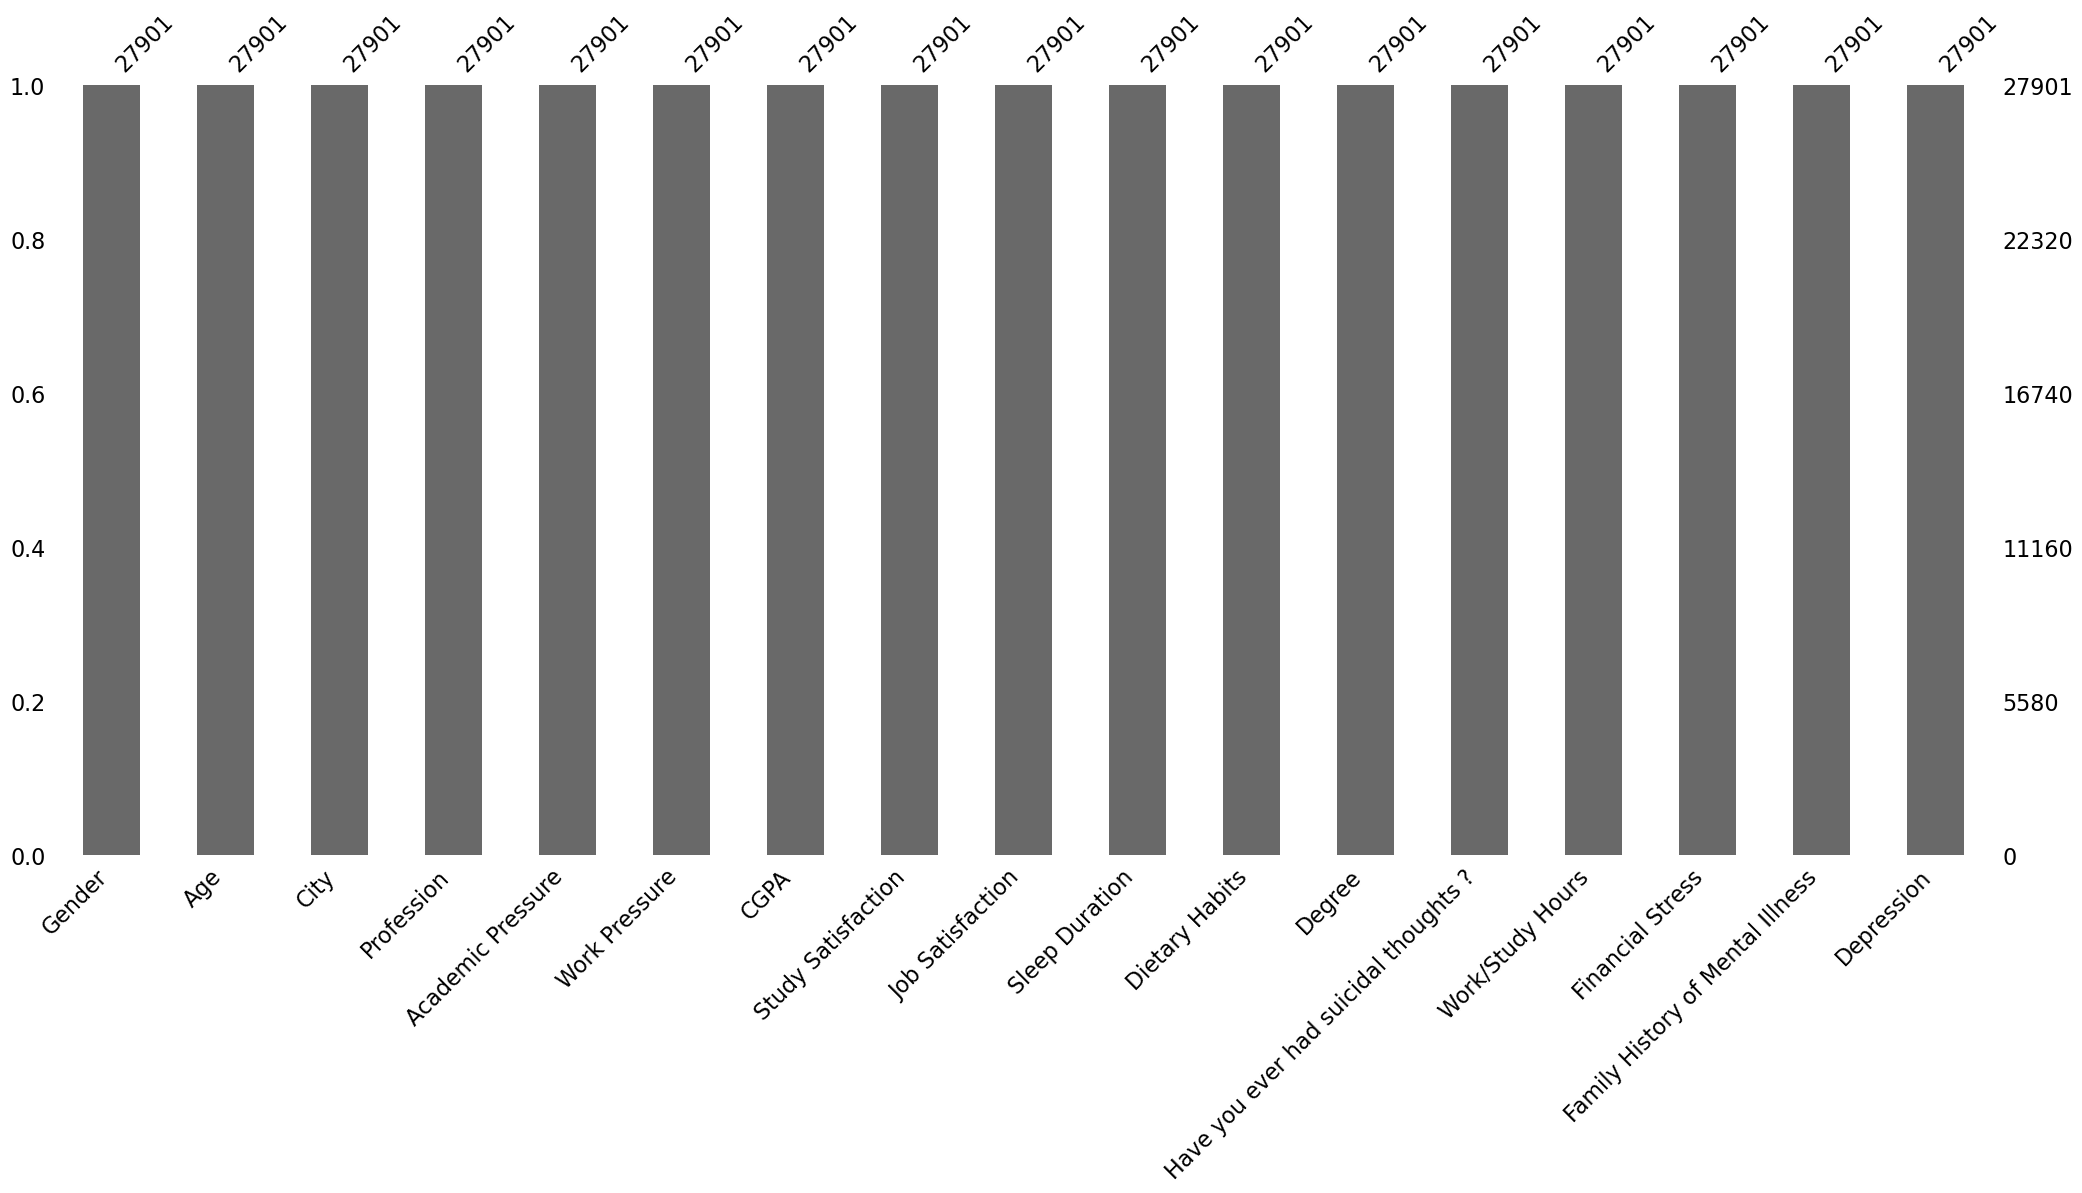

In [121]:
import missingno as msno
%matplotlib inline
msno.bar(df)

From this chart we can see that there aren't NaN values in dataset.

In [122]:
columns_for_plotting = df.select_dtypes(include=['int', 'float']).columns
columns_for_plotting

Index(['Age', 'Academic Pressure', 'Work Pressure', 'CGPA',
       'Study Satisfaction', 'Job Satisfaction', 'Work/Study Hours',
       'Depression'],
      dtype='object')

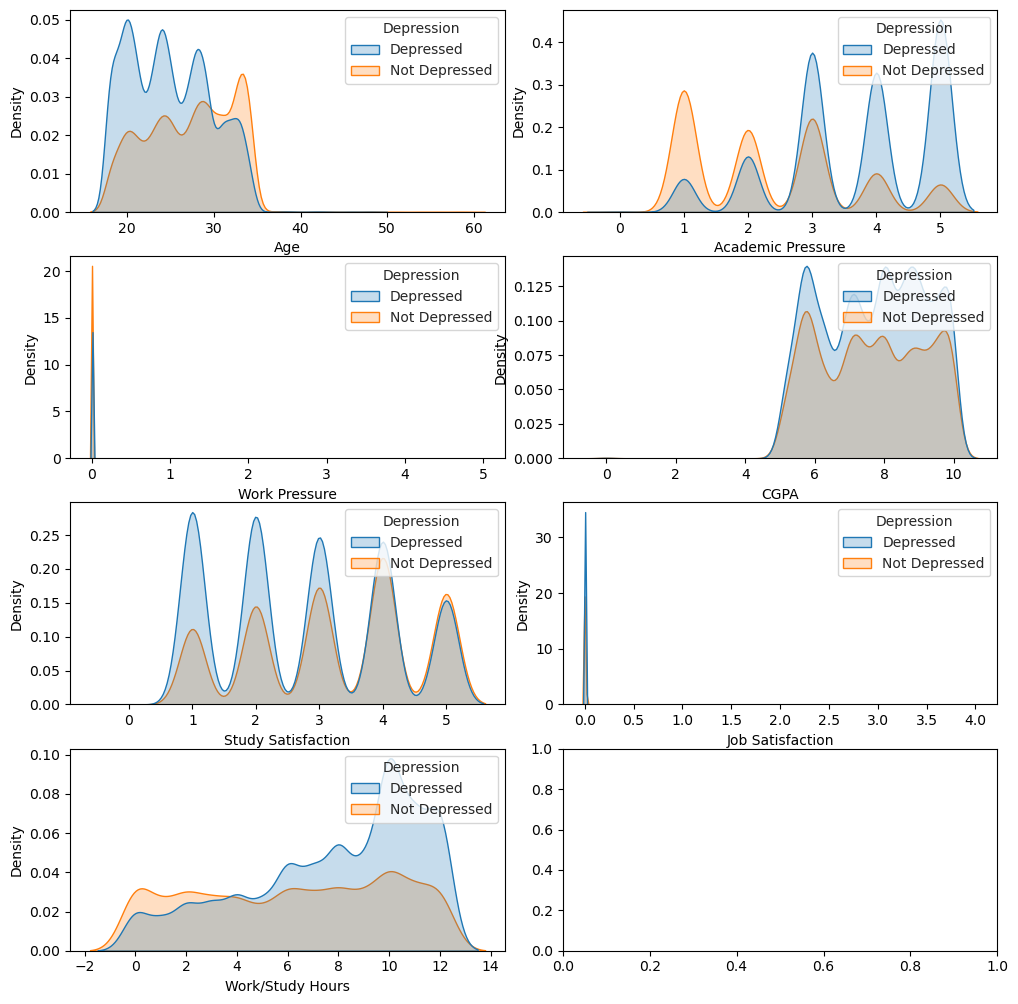

In [123]:
from matplotlib import pyplot as plt
import seaborn as sns

columns_for_plotting = ['Age', 'Academic Pressure', 'Work Pressure', 'CGPA', 'Study Satisfaction', 'Job Satisfaction', 'Work/Study Hours','Depression']
fig, axes = plt.subplots(4, 2, figsize=(10, 10))
fig.tight_layout() 

category = df.copy() 
category["Depression"] = category["Depression"].astype(str) # a warning raises if the 
category.loc[category["Depression"] == "1", "Depression"] = "Depressed"
category.loc[category["Depression"] == "0", "Depression"]  = "Not Depressed"

axes = axes.flatten()
with sns.axes_style("whitegrid"):
    for i, column in enumerate(pd.DataFrame(columns=columns_for_plotting).drop('Depression', axis=1)):
        sns.kdeplot(category, x=column , hue="Depression", fill=True, ax = axes[i])

Let's draw some conclusions from these charts. Firstly we could observe that the **Age** is inverse correlated with the Depression also this could be observed for the **Study Satisfaction**. But also we can observe two features that are directly correlated **Academic Pressure**, **Work/Study Hours**. 

From **Work Pressure** and **Job Satisfaction** graphs I assume that there are values different from 0, but they are so few that I consider to drop the jobs any feature related to it. 

In [124]:
category.head()

,Gender,Age,City,Profession,Academic Pressure,Work Pressure,CGPA,Study Satisfaction,Job Satisfaction,Sleep Duration,Dietary Habits,Degree,Have you ever had suicidal thoughts ?,Work/Study Hours,Financial Stress,Family History of Mental Illness,Depression
0,Male,33.0,Visakhapatnam,Student,5.0,0.0,8.97,2.0,0.0,'5-6 hours',Healthy,B.Pharm,Yes,3.0,1.0,No,Depressed
1,Female,24.0,Bangalore,Student,2.0,0.0,5.90,5.0,0.0,'5-6 hours',Moderate,BSc,No,3.0,2.0,Yes,Not Depressed
2,Male,31.0,Srinagar,Student,3.0,0.0,7.03,5.0,0.0,'Less than 5 hours',Healthy,BA,No,9.0,1.0,Yes,Not Depressed
3,Female,28.0,Varanasi,Student,3.0,0.0,5.59,2.0,0.0,'7-8 hours',Moderate,BCA,Yes,4.0,5.0,Yes,Depressed
4,Female,25.0,Jaipur,Student,4.0,0.0,8.13,3.0,0.0,'5-6 hours',Moderate,M.Tech,Yes,1.0,1.0,No,Not Depressed


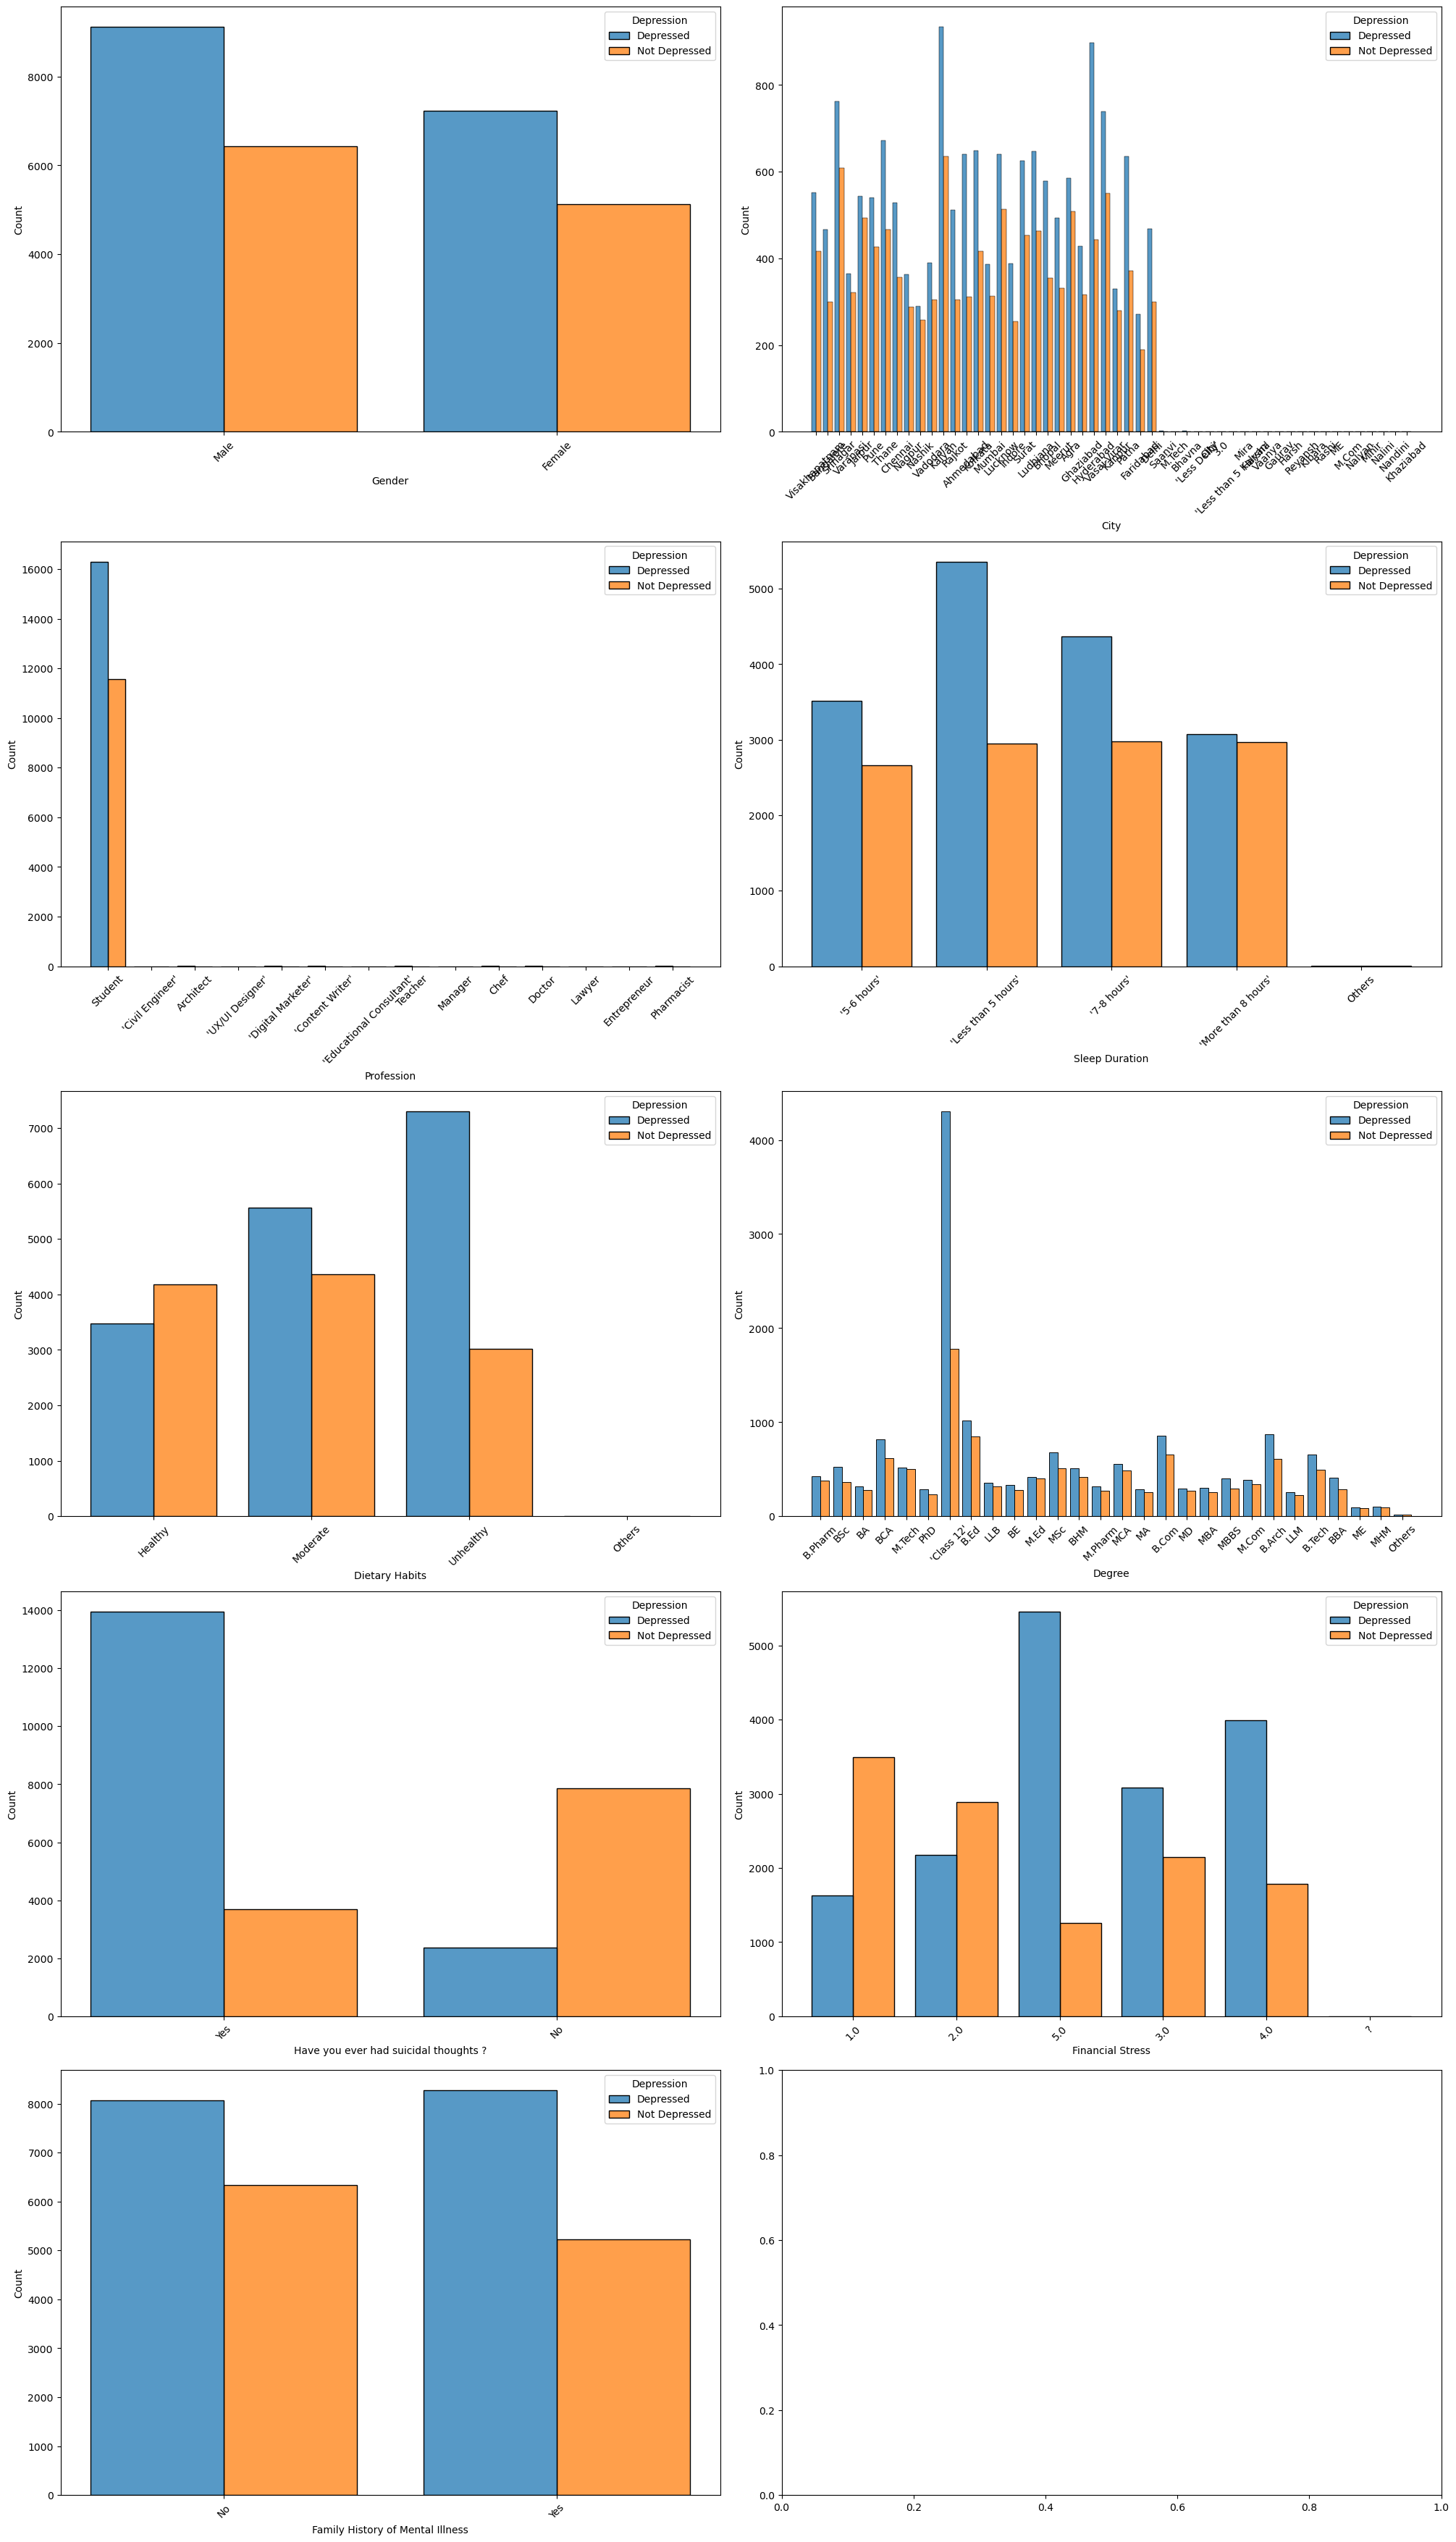

In [125]:
import seaborn as sns


fig, axes = plt.subplots(5, 2, figsize=(20, 35), constrained_layout=True)
axes = axes.flatten()
# fig.tight_layout() 

category = df.drop(columns_for_plotting[:-1], axis=1).copy() 
category["Depression"] = category["Depression"].astype(str) # a warning raises if the 
category.loc[category["Depression"] == "1", "Depression"] = "Depressed"
category.loc[category["Depression"] == "0", "Depression"]  = "Not Depressed"

for i, column in enumerate(category.columns[:-1]):
    ax =  sns.histplot( data=category, x=column, hue="Depression", multiple="dodge", ax=axes[i], shrink=.8)
    ax.tick_params(axis='x', labelrotation = 45)

Here I want to point out:
- As mentioned above I consider to remove all features related to the jobs things because we could se here also that the most significant value of Profession is Student.
- Also, we could see that causes of the depression are intuitive for example we see that there is an increase in nr of Depressed people that sleep lesser hours have unhealthy dietary habits had suicidal thoughts and have a high financial stress. 

In [126]:
len(df.loc[df["Financial Stress"] == "?"])

3

In [127]:
len(df.loc[df["Sleep Duration"] == "Others"])

18

In [128]:
len(df.loc[df["Dietary Habits"] == "Others"])

12

There are few values of "Others" and "?" therefor to not complicate my self I will just delete them.

In [129]:
df = df.loc[df["Financial Stress"] != "?"]
df = df.loc[df["Sleep Duration"] != "Others"]
df = df.loc[df["Dietary Habits"] != "Others"]

Now I would like to transform data into numeric values. 


Here I could apply dummy variables for **Gender**, **Have you ever had suicidal thoughts?**, **Family History of Mental illness**, but I prefer Label Encoder because it gives me more control and I could use it for other columns.
Here is another thing I fell I need to explain, why did I apply label encoding for values like **Dietary Habits**? I did it because the labels behind are just some increasing rating.

In [130]:
from sklearn.preprocessing import LabelEncoder

labels = {
    "Gender" : ["Female", "Male"], # 0, 1
    "Have you ever had suicidal thoughts ?": ["No", "Yes"], # 0, 1
    "Family History of Mental Illness": ["No", "Yes"], # 0, 1
    "Financial Stress": ['1.0', '2.0', '3.0', '4.0', '5.0'], # 0, 1, 2, 3, 4
    "Dietary Habits" : ["Unhealthy", "Moderate", "Healthy"], # 0, 1, 2
}

for column, feature_values in labels.items():
    label_encoder = LabelEncoder()
    label_encoder.fit(feature_values)
    df[column] = label_encoder.transform(df[column])

Now I would like to assign for each label of sleep hours a rank. where 'more than 8 hours' will be a 10, 'lesser than 5' a 1,  '7-8 hours' will be 8, '5-6 hours will be a 10'. How did establish this values? (intuition, and my own experience of sleep)

In [131]:
df.loc[:,"Sleep Duration"].unique()

array(["'5-6 hours'", "'Less than 5 hours'", "'7-8 hours'",
       "'More than 8 hours'"], dtype=object)

In [132]:

sleep_labels = {
    "'Less than 5 hours'":1,
    "'5-6 hours'": 5,
    "'7-8 hours'":8,
    "'More than 8 hours'":10
}

for label, value in sleep_labels.items():
    df.loc[df["Sleep Duration"] == label, 'Sleep Duration'] = value

In [133]:
df.head()

,Gender,Age,City,Profession,Academic Pressure,Work Pressure,CGPA,Study Satisfaction,Job Satisfaction,Sleep Duration,Dietary Habits,Degree,Have you ever had suicidal thoughts ?,Work/Study Hours,Financial Stress,Family History of Mental Illness,Depression
0,1,33.0,Visakhapatnam,Student,5.0,0.0,8.97,2.0,0.0,5,0,B.Pharm,1,3.0,0,0,1
1,0,24.0,Bangalore,Student,2.0,0.0,5.90,5.0,0.0,5,1,BSc,0,3.0,1,1,0
2,1,31.0,Srinagar,Student,3.0,0.0,7.03,5.0,0.0,1,0,BA,0,9.0,0,1,0
3,0,28.0,Varanasi,Student,3.0,0.0,5.59,2.0,0.0,8,1,BCA,1,4.0,4,1,1
4,0,25.0,Jaipur,Student,4.0,0.0,8.13,3.0,0.0,5,1,M.Tech,1,1.0,0,0,0


Now for the cities, I will do something new for me. 

In [135]:
all_cities = df.City.unique()
all_cities

array(['Visakhapatnam', 'Bangalore', 'Srinagar', 'Varanasi', 'Jaipur',
       'Pune', 'Thane', 'Chennai', 'Nagpur', 'Nashik', 'Vadodara',
       'Kalyan', 'Rajkot', 'Ahmedabad', 'Kolkata', 'Mumbai', 'Lucknow',
       'Indore', 'Surat', 'Ludhiana', 'Bhopal', 'Meerut', 'Agra',
       'Ghaziabad', 'Hyderabad', 'Vasai-Virar', 'Kanpur', 'Patna',
       'Faridabad', 'Delhi', 'Saanvi', 'M.Tech', 'Bhavna', "'Less Delhi'",
       'City', '3.0', "'Less than 5 Kalyan'", 'Mira', 'Harsha', 'Vaanya',
       'Gaurav', 'Harsh', 'Reyansh', 'Kibara', 'Rashi', 'ME', 'M.Com',
       'Nalyan', 'Mihir', 'Nalini', 'Nandini', 'Khaziabad'], dtype=object)

So I did some chitchatting with the claude and found out that not all this values are actually cities. For example "City" or "3.0". These values are probably miss imputations.

In [137]:
real_indian_cities = [
    'Visakhapatnam',
    'Bangalore',
    'Srinagar',
    'Varanasi',
    'Jaipur',
    'Pune',
    'Thane',
    'Chennai',
    'Nagpur',
    'Nashik',
    'Vadodara',
    'Kalyan',
    'Rajkot',
    'Ahmedabad',
    'Kolkata',
    'Mumbai',
    'Lucknow',
    'Indore',
    'Surat',
    'Ludhiana',
    'Bhopal',
    'Meerut',
    'Agra',
    'Ghaziabad',
    'Hyderabad',
    'Vasai-Virar',
    'Kanpur',
    'Patna',
    'Faridabad',
    'Delhi'
]

this value I know that is a misspelling. There are probably more misspelling cities but i am not an expert in indian cities therefor I will remove other values that are not actual cities.

In [ ]:
df.loc[df["City"] == "Khaziabad", 'Khaziabad'] = "Ghaziabad"

In [141]:
for city in all_cities:
    df = df.loc[not df["City"] in real_indian_cities]        

ValueError: The truth value of a Series is ambiguous. Use a.empty, a.bool(), a.item(), a.any() or a.all().